In [461]:
"""
Try simulating bipolar oscillation with quimb
"""

'\nTry simulating bipolar oscillation with quimb\n'

In [462]:
from tqdm import tqdm

In [463]:
%load_ext autoreload
%autoreload 2
%autosave 0
%precision %g

import sys, os, glob, time
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as lines
import functools as ft
import numpy as np
import numpy.random as rnd
import scipy.integrate as integ
import qiskit as qk
import qiskit_aer as aer
import qiskit_algorithms as qalgo
import qiskit_ibm_runtime as qkrun
import qiskit_experiments as qkexp
import qiskit_braket_provider as braket

# Launch Wolfram language interface
# from wolframclient.evaluation import WolframLanguageSession
# from wolframclient.language import wl, wlexpr
# wl_session = WolframLanguageSession()

from tqdm import tqdm

import sys

sys.path.append("../")

# Directories
# if os.uname().sysname == 'Linux':
#     base_dir = os.path.expanduser("~/sn-quant/")
# else:
#     base_dir = os.path.expanduser("~/Dropbox/sn-quant/jk/")

base_dir = os.path.join("../", "joachim")
os.chdir(base_dir)

# set up matplotlib
%matplotlib inline
# matplotlib.rcParams['text.usetex']    = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
matplotlib.rcParams['font.family']    = 'serif'
matplotlib.rcParams['font.size']      = '16'
# matplotlib.rcParams['figure.figsize'] = 6.4, 4.8
matplotlib.rcParams['figure.figsize'] = 16, 8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV     = 1.
    keV    = 1.e3
    MeV    = 1.e6
    GeV    = 1.e9
    TeV    = 1.e12
    PeV    = 1.e15
    kg     = 5.62e35*eV
    grams  = 0.001*kg
    Kelvin = 8.617333262e-5       # PDG 2022
    Joule  = 1/1.602176634e-19*eV # PDG 2022 [exact]
    erg    = 1e-7*Joule
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hours = 3600*sec
    days  = 24*hours
    yrs   = 365*days
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h        = 0.674                         # according to Planck 2018
    H0       = h * 100. * km / sec/ Mpc      # Hubble parameter
    rho_c0   = 3. * H0**2/(8. * np.pi * GN)  # critical density today, Kolb Turner eq. (3.14)
    Omega_dm = 0.12 / h**2                   # dark matter density, Planck 2018
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    GF       = 1.166378e-5 / GeV**2          # Fermi constant (PDG 2022)
    s2thW    = 1.03232 * 0.23121             # sin^2 \theta_W(M_Z) from PDG 2022; \kappa from https://arxiv.org/abs/1608.02671
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    gA       = 1.26                          # axial coupling constant of the proton
    
    # PDG codes
    pdg_nu_e      = 12
    pdg_nu_mu     = 14
    pdg_nu_tau    = 16
    pdg_e         = 11
    pdg_mu        = 13
    pdg_tau       = 15
    pdg_gamma     = 22
    pdg_pip       = 211
    pdg_pi0       = 111
    pdg_KL        = 130
    pdg_Kp        = 321
    pdg_Dp        = 411
    pdg_D0        = 421
    pdg_Dp2s_2460 = 415
    pdg_D02s_2460 = 425
    pdg_Dsp       = 431
    pdg_Dsps      = 433
    pdg_Ds2s_2573 = 435
    
u = my_units()

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]])
sigma_1 = np.array([[0, 1],  [1,  0]])
sigma_2 = np.array([[0,-1j], [1j, 0]])
sigma_3 = np.array([[1, 0],  [0, -1]])


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosave disabled


In [464]:
from scipy.linalg import expm

def self_interact_nunu(theta):
    """
    returns the interaction term for nunu and nubarnubar interactions
    Friedland & Lunardini type
    """

    block = np.asarray([
        [2, 0, 0, 0],
        [0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 0, 0, 2]
    ])

    return expm(-1j * theta * block)

def self_interact_nunubar(theta):
    """
    returns the interaction term for nunubar interactions
    """

    block = np.asarray([
        [-2, 0, 0, -1],
        [0, -1, 0, 0],
        [0, 0, -1, 0],
        [-1, 0, 0, -2]
    ])

    return expm(-1j * theta * block)

In [465]:
import sys

sys.path.append("../")
from utils.Collector import Collector
cl = Collector()

In [ ]:
L          = 1
t_steps    = 64
theta      = np.pi/2 - 0.2
dmsq       = 1.0
n_qubits   = 8
#@FIXME
Delta      = dmsq / (2*0.1) * np.array([1.] * (n_qubits // 2) + [1.] * (n_qubits // 2))
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((n_qubits, n_qubits))
nu_mask    = [True]*(n_qubits // 2) + [False] * (n_qubits // 2)
nubar_mask = [False]*(n_qubits // 2) + [True] * (n_qubits // 2)


# Set up the discretization
t_table = np.linspace(0, L, t_steps)
dt_table       = np.diff(t_table)

qc = qk.QuantumCircuit(n_qubits)

REMOVE_ENTANGLE = True

for iq in range(n_qubits): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
    if nubar_mask[iq]:
        qc.x(iq)

for i in tqdm(range(len(dt_table))):
    dt = dt_table[i]

    if REMOVE_ENTANGLE:

    # artificially remove entanglement by resetting each qubit to a non-entangled state
        qc_no_save = qc.remove_final_measurements(inplace=False)
        qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
        sv = qk.quantum_info.Statevector(qc_no_save)
        rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
        p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]
        
        # reset qubits to a non-entangled state to emulate the mean-field picture
        qc.reset(range(n_qubits))
        for j in range(n_qubits):
            qc.ry(np.arccos(p[j][2]), j)
            qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    qc.save_density_matrix(label=str(i+1))

    for j in range(n_qubits):
        qc.rx(-dt*Delta[j]*b[0], j)
        qc.rz(-dt*Delta[j]*b[2], j)

    for iq1 in range(n_qubits):
        for iq2 in range(iq1+1, n_qubits):
            if nu_mask[iq1] ^ nu_mask[iq2]:
                # qc.rxx(-dt*J[iq1, iq2], iq1, iq2)
                # qc.ryy(-dt*J[iq1, iq2], iq1, iq2)
                # qc.rzz(-dt*J[iq1, iq2], iq1, iq2)
                qc.unitary(self_interact_nunu(-dt*J[iq1, iq2]), [iq1, iq2])
            else:
                # qc.rxx(-dt*J[iq1, iq2], iq1, iq2)
                # qc.ryy(-dt*J[iq1, iq2], iq1, iq2)
                # qc.rzz(-dt*J[iq1, iq2], iq1, iq2)
                # qc.unitary(self_interact_nunubar(-dt*J[iq1, iq2]), [iq1, iq2])
                qc.unitary(self_interact_nunu(-dt*J[iq1, iq2]), [iq1, iq2])

# save final state
qc.save_density_matrix(label=str(i+2))

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

100%|██████████| 63/63 [00:07<00:00,  8.35it/s]


In [467]:

# # Neutrino Neutrino setup

# L          = 1
# t_steps    = 50
# theta      = np.pi/2 - 0.2
# dmsq       = 1.0
# n_qubits   = 8
# Delta = dmsq / (2*0.1) * np.array([1.] * n_qubits)
# b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
# J          = 5 * np.ones((n_qubits, n_qubits))
# nu_mask   = [True] * n_qubits
# nubar_mask = [False] * n_qubits

# # Set up the discretization
# t_table = np.linspace(0, L, t_steps)
# dt_table       = np.diff(t_table)

# qc = qk.QuantumCircuit(n_qubits)

# REMOVE_ENTANGLE = True

# # for iq in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
# #     qc.x(iq)
# # for iq in range(n_qubits//2, n_qubits): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
# #     qc.x(iq)

# for i in tqdm(range(len(dt_table))):
#     dt = dt_table[i]

#     if REMOVE_ENTANGLE:

#     # artificially remove entanglement by resetting each qubit to a non-entangled state
#         qc_no_save = qc.remove_final_measurements(inplace=False)
#         qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
#         sv = qk.quantum_info.Statevector(qc_no_save)
#         rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
#         p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]
        
#         # reset qubits to a non-entangled state to emulate the mean-field picture
#         qc.reset(range(n_qubits))
#         for j in range(n_qubits):
#             qc.ry(np.arccos(p[j][2]), j)
#             qc.rz(np.arctan2(p[j][1], p[j][0]), j)

#     qc.save_density_matrix(label=str(i+1))

#     for j in range(n_qubits):
#         qc.rx(-dt*Delta[j]*b[0], j)
#         qc.rz(-dt*Delta[j]*b[2], j)
    
#     # for iq1 in range(n_qubits):
#     #     for iq2 in range(iq1+1, n_qubits):
#     #         if nu_mask[iq1] ^ nu_mask[iq2]: # nunu or nubarnubar
#     #             qc.unitary(self_interact_nunu(J[iq1, iq2] * dt), [iq1, iq2], label='nunu')
#     #         else:
#     #             qc.unitary(self_interact_nunubar(J[iq1, iq2] * dt), [iq1, iq2], label='nunubar')

#     for iq1 in range(n_qubits):
#         for iq2 in range(iq1+1, n_qubits):
#             if nu_mask[iq1] ^ nu_mask[iq2]:
#                 # qc.rxx(-dt*J[iq1, iq2], iq1, iq2)
#                 # qc.ryy(-dt*J[iq1, iq2], iq1, iq2)
#                 # qc.rzz(-dt*J[iq1, iq2], iq1, iq2)
#                 qc.unitary(self_interact_nunu(-dt*J[iq1, iq2]), [iq1, iq2])
#             else:
#                 # qc.rxx(-dt*J[iq1, iq2], iq1, iq2)
#                 # qc.ryy(-dt*J[iq1, iq2], iq1, iq2)
#                 # qc.rzz(-dt*J[iq1, iq2], iq1, iq2)
#                 qc.unitary(self_interact_nunu(-dt*J[iq1, iq2]), [iq1, iq2])

# # save final state
# qc.save_density_matrix(label=str(i+2))

# # run simulation    
# sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
# result = sim.run(qc).result()

Obtaining partial traces ...


100%|██████████| 8/8 [00:00<00:00, 13294.15it/s]
python(67129) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67130) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Finished calculation for qubit 0
Finished calculation for qubit 1
Finished calculation for qubit 2
Finished calculation for qubit 3
Finished calculation for qubit 4
Finished calculation for qubit 5
Finished calculation for qubit 6
Finished calculation for qubit 7
Calculating probabilities ...


Text(0.9, 0.9, '$\\theta = 78.54$')

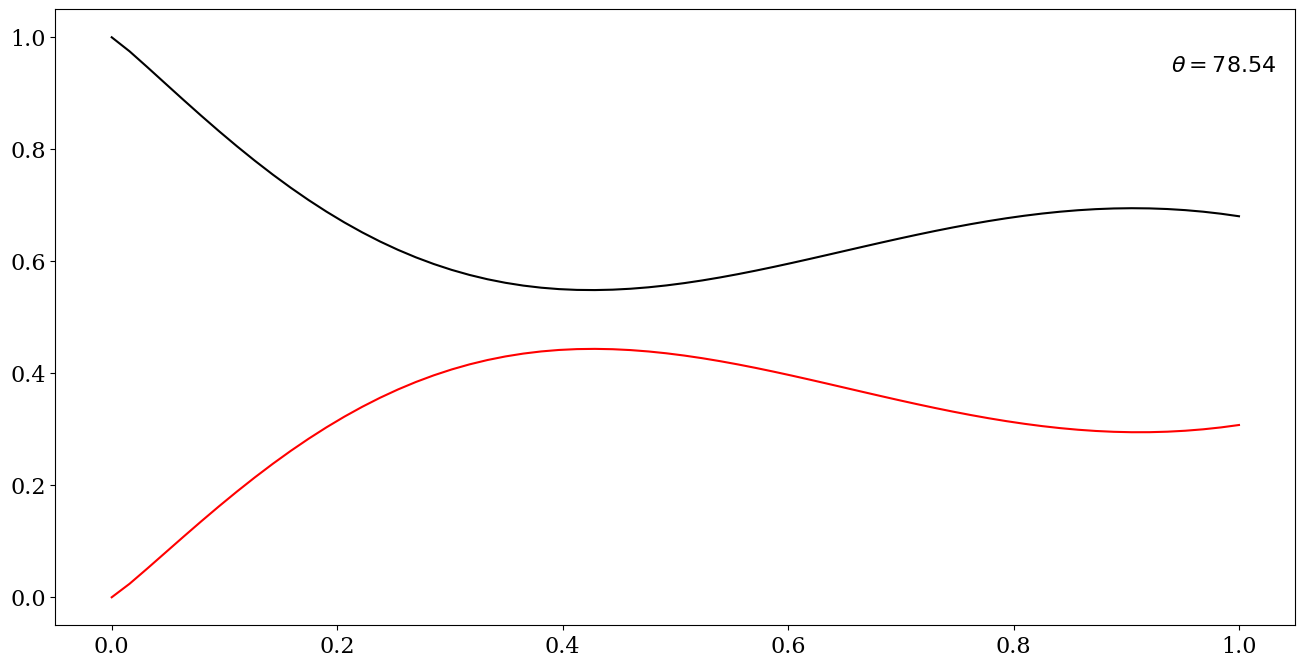

In [468]:
# extract and plot results
n_qubits = qc.num_qubits
rho_data = [result.data()[k] for k in result.data().keys()]  # assume keys are times

from joblib import Parallel, delayed

def reduce_qubit(j):
    tmp = { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() }
    print("Finished calculation for qubit", j)
    return tmp

print("Obtaining partial traces ...")

rho_reduced = Parallel(n_jobs=-1)(delayed(reduce_qubit)(j) for j in tqdm(range(n_qubits)))

print("Calculating probabilities ...")

# rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in tqdm(range(n_qubits)) ]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in range(n_qubits) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))

for j in [0, 7]:
    color = 'black' if j < n_qubits // 2 else 'red'
    plt.plot(t_table, pp[j,:, 1], color=color)

for j in range(n_qubits):
    cl.add(f"{n_qubits}_quantum_single_{j}", pp[j,:, 1])

plt.text(0.9, 0.9, f"$\\theta = {(theta / np.pi * 180):.2f}$", transform=plt.gca().transAxes, fontsize=16)

In [469]:
"""
Functions taken from bipolar-oscillations.ipynb, Raffelt–Sigl Polarization-Vector Approach to Collective Oscillations
"""

def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           initial_flavors: an array of length n_modes indicating the initial flavor of
                    each neutrino ('e', 'x', or 'a'). If any neutrino has flavor 'a',
                    an angle alpha must be specified.
           alpha:   initial superposition for neutrinos in flavor 'a'
    """
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.squeeze(np.array([0, 0,  1.]))
    Emu = np.squeeze(np.array([0, 0, -1.]))
    B   = np.real(np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)]))
    L   = np.real(np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)]))
    
    ini_state = np.where(omega>0, Ee[:,None], Emu[:,None])
    if initial_flavors is not None:
        for f in initial_flavors:
            if f not in ['e','x','mu','a']:
                raise ValueError(f'Unknown flavor: {f}')
            if f == 'a' and alpha is None:
                raise ValueError('Initial superposition for neutrinos in flavor "a" not specified')
        for ifi in range(len(initial_flavors)):
            if initial_flavors[ifi] == 'e':
                ini_state[:,ifi] = Ee[:]
            elif initial_flavors[ifi] == 'x':
                ini_state[:,ifi] = Emu[:]
            elif initial_flavors[ifi] == 'mu':
                ini_state[:,ifi] = Emu[:]
            elif initial_flavors[ifi] == 'a':
                # FIXME I'm not sure this is correct
                ini_state[:,ifi] = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:]

        # ini_state[:,initial_flavors=='e']  = Ee[:,None]
        # ini_state[:,initial_flavors=='x']  = Emu[:,None]
        # ini_state[:,initial_flavors=='mu'] = Emu[:,None]
        # ini_state[:,initial_flavors=='a']  = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:,None]
        # FIXME I'm not sure this is correct
        
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            if k >= n_modes // 2:
                res[3*k:3*k+3] = np.cross(-omega[k]*B + lam*L - PP@J[k,:], PP[:,k])
            else:
                res[3*k:3*k+3] = np.cross(omega[k]*B + lam*L + PP@J[k,:], PP[:,k])

            # per paper
            # res[3*k:3*k+3] = np.cross(omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res

    return integ.solve_ivp(f, (t_table[0],t_table[-1]), ini_state.T.flatten(), t_eval=t_table)

def P_osc_RS_bipolar(t_table, theta, omega, lam, J, eps=0.1):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach for
       a bipolar system.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           eps:     asymmetry between neutrinos and anti-neutrinos"""
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller, Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1+eps])
    Emu = np.array([0, 0, -1+eps])
    B   = np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)])
    L   = np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)])
    
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = (0+0j)*np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            s  = 1 if k < n_modes//2 else -1
            res[3*k:3*k+3] = np.cross(s*omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res
            
    E0 = np.concatenate((np.tile(Ee,n_modes//2), np.tile(Emu,n_modes//2)))
    return integ.solve_ivp(f, (t_table[0],t_table[-1]), E0, t_eval=t_table)    

def U_self_int(theta):
   """the exponential of the neutrino interaction Hamiltonian,
      see Friedland & Lunardini, https://arxiv.org/abs/hep-ph/0304055
   """
   return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                  [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                  [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                  [0,                 0,                          0,                          np.exp(-1j*theta)]])


In [470]:
# """
# Set up to evaluate classical solution for nunu

# Working on 4 neutrino case, 2 neutrinos and 2 antineutrinos.
# """

# L          = 1
# t_steps    = 50
# theta      = np.pi/2 - 0.2
# dmsq       = 1.0
# n_qubits   = 8
# Delta      = dmsq / (2*0.1) * np.array([1.] * (n_qubits // 2) + [1.0] * (n_qubits // 2))
# # Delta = dmsq / (2*0.1) * np.array([1.] * n_qubits)
# b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
# J          = 5 * np.ones((n_qubits, n_qubits))
# # nu_mask    = [True]*(n_qubits // 2) + [False] * (n_qubits // 2)
# # nubar_mask = [False]*(n_qubits // 2) + [True] * (n_qubits // 2)
# nu_mask = [True] * n_qubits
# nubar_mask = [False] * n_qubits

# initial_flavors = ['e'] * n_qubits

# # mean-field solution
# L_table = np.linspace(0, L, t_steps)
# sol     = P_osc_RS(L_table, theta, Delta, 0., abs(J), initial_flavors = initial_flavors) # factor 2 because we compare to a system with 2 nu + 2 nubar
# P_table = np.reshape(sol.y, (n_qubits,3,len(L_table)))

# plt.plot(L_table, 0.5*(1+P_table[0,2,:]), ls=':', lw=3)
# plt.plot(L_table, 0.5*(1+P_table[-1,2,:]), ls=':', lw=3)

# plt.plot(t_table, pp[0,:, 1], color='orange')
# plt.plot(t_table, pp[-1,:, 1], color='blue')

# cl.add("classical_nu", np.squeeze(0.5*(1-P_table[0,2,:])))
# cl.add("classical_nubar", np.squeeze(0.5*(1-P_table[1,2,:])))

# plt.title("Case (3) e*8, FL")

Text(0.5, 1.0, 'Case (9) 5a-5b e*4+ebar*4, -vac, xyz')

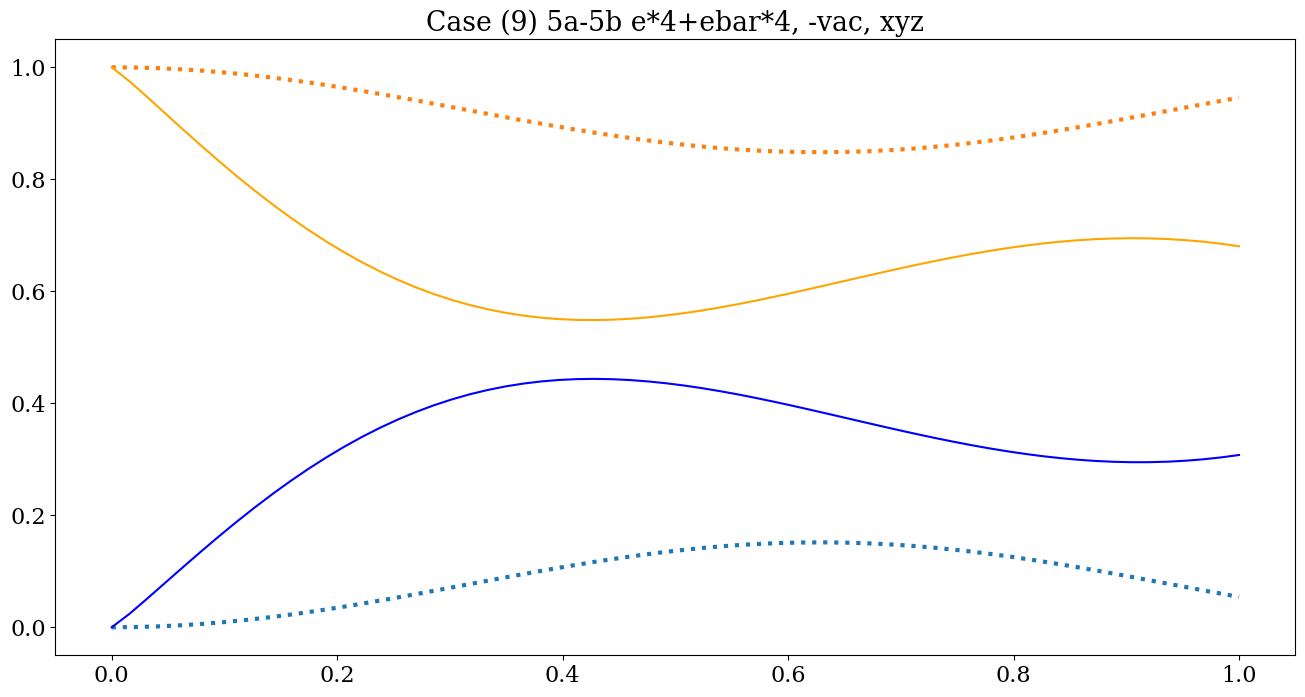

In [ ]:
"""
Set up to evaluate classical solution for nunubar

Working on 4 neutrino case, 2 neutrinos and 2 antineutrinos.
"""

L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.2
dmsq       = 1.0
n_qubits   = 8
Delta      = dmsq / (2*0.1) * np.array([1.] * (n_qubits // 2) + [-1.0] * (n_qubits // 2))
# Delta = dmsq / (2*0.1) * np.array([1.] * n_qubits)
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((n_qubits, n_qubits))
nu_mask    = [True]*(n_qubits // 2) + [False] * (n_qubits // 2)
nubar_mask = [False]*(n_qubits // 2) + [True] * (n_qubits // 2)

# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, Delta, 0., abs(J)) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (n_qubits,3,len(L_table)))

plt.plot(L_table, 0.5*(1-P_table[0,2,:]), ls=':', lw=3)
plt.plot(L_table, 0.5*(1-P_table[-1,2,:]), ls=':', lw=3)

plt.plot(t_table, pp[0,:, 1], color='orange')
plt.plot(t_table, pp[-1,:, 1], color='blue')

cl.add("classical_nu", np.squeeze(0.5*(1-P_table[0,2,:])))
cl.add("classical_nubar", np.squeeze(0.5*(1-P_table[1,2,:])))

plt.title("Case (10) 5a-5b e*4+ebar*4, -vac, FL(nu)")